In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import math
import numpy as np
import matplotlib.pyplot as plt

import qpe

In [2]:
checks = qpe.check_qft(4)
for key, label in (("matrix", "circuit vs. the Fourier matrix"),
                   ("product_form", "circuit vs. the product form"),
                   ("fft", "circuit vs. numpy.fft"),
                   ("inverse", "inverse QFT o QFT = identity"),
                   ("unitary", "assembled circuit is unitary")):
    print(f"{label:<36s} {checks[key]:.2e}")
print()
print("The second line is the one that matters: the product form is built")
print("with no circuit at all, straight from the binary-fraction")
print("factorisation, so agreement tests the derivation and not merely the")
print("implementation's self-consistency.")

circuit vs. the Fourier matrix       3.78e-15
circuit vs. the product form         1.89e-16
circuit vs. numpy.fft                2.42e-16
inverse QFT o QFT = identity         2.99e-16
assembled circuit is unitary         6.66e-16

The second line is the one that matters: the product form is built
with no circuit at all, straight from the binary-fraction
factorisation, so agreement tests the derivation and not merely the
implementation's self-consistency.


    k                  amplitude     |amp|   phase/2pi  5k/8 mod 1
  000   +0.353553  +0.000000i  0.353553    0.000000    0.000000
  001   -0.250000  -0.250000i  0.353553    0.625000    0.625000
  010   +0.000000  +0.353553i  0.353553    0.250000    0.250000
  011   +0.250000  -0.250000i  0.353553    0.875000    0.875000
  100   -0.353553  +0.000000i  0.353553    0.500000    0.500000
  101   +0.250000  +0.250000i  0.353553    0.125000    0.125000
  110   -0.000000  -0.353553i  0.353553    0.750000    0.750000
  111   -0.250000  +0.250000i  0.353553    0.375000    0.375000

every modulus is 1/sqrt(8) = 0.353553, and the phase of
|k> is 5k/8 mod 1 -- the Fourier kernel with x = 5, as it must be.


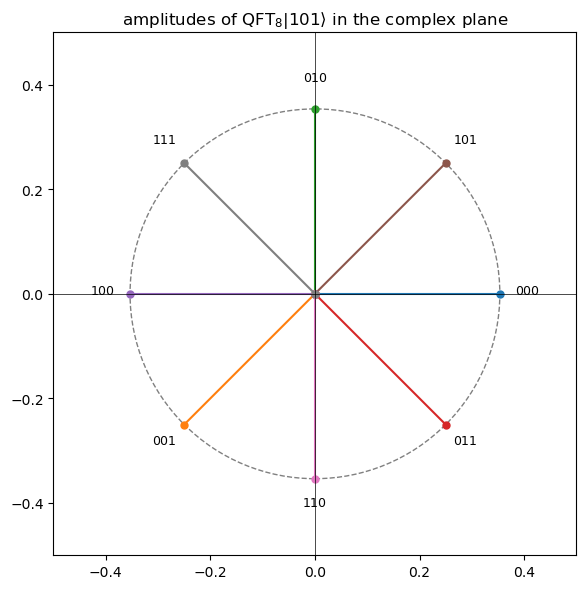

In [3]:
state = qpe.qft(qpe.basis_state("101"), 3)
print(f"{'k':>5s} {'amplitude':>26s} {'|amp|':>9s} {'phase/2pi':>11s} {'5k/8 mod 1':>11s}")
for k in range(8):
    a = state[k]
    print(f"{qpe.bitstring(k,3):>5s} {a.real:+11.6f}{a.imag:+11.6f}i "
          f"{abs(a):9.6f} {np.angle(a)/(2*math.pi) % 1.0:11.6f} "
          f"{(5*k/8) % 1.0:11.6f}")
print()
print(f"every modulus is 1/sqrt(8) = {1/math.sqrt(8):.6f}, and the phase of")
print("|k> is 5k/8 mod 1 -- the Fourier kernel with x = 5, as it must be.")

fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), 1/math.sqrt(8), fill=False, ls="--", color="gray")
ax.add_artist(circle)
for k in range(8):
    ax.plot([0, state[k].real], [0, state[k].imag], "-o", ms=5)
    ax.annotate(qpe.bitstring(k, 3), (state[k].real*1.15, state[k].imag*1.15),
                ha="center", fontsize=9)
ax.set_aspect("equal"); ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title(r"amplitudes of $\mathrm{QFT}_8|101\rangle$ in the complex plane")
plt.tight_layout(); plt.show()

    n     H   controlled R   swaps    direct DFT
    3     3              3       1       6.4e+01
    6     6             15       3       4.1e+03
   10    10             45       5       1.0e+06
  100   100           4950      50       1.6e+60

d = 1:  0 rotations, max amplitude error 2.497e-01
d = 2:  5 rotations, max amplitude error 2.425e-01
d = 3:  9 rotations, max amplitude error 1.285e-01
d = 4: 12 rotations, max amplitude error 3.668e-02
d = 5: 14 rotations, max amplitude error 1.227e-02
d = 6: 15 rotations, max amplitude error 0.000e+00


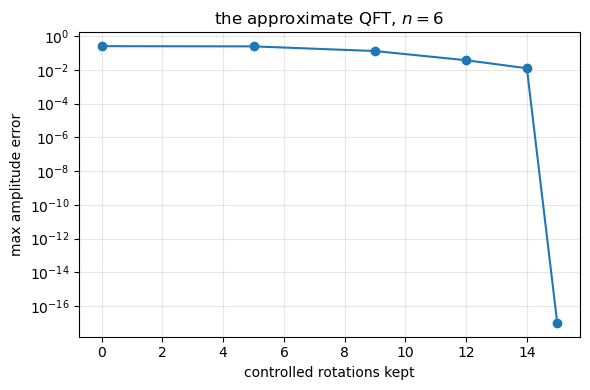

In [4]:
print(f"{'n':>5s} {'H':>5s} {'controlled R':>14s} {'swaps':>7s} {'direct DFT':>13s}")
for n in (3, 6, 10, 100):
    h, r, s = qpe.gate_counts(n)
    classical = f"{4.0**n:.1e}" if n <= 10 else "1.6e+60"
    print(f"{n:5d} {h:5d} {r:14d} {s:7d} {classical:>13s}")

print()
ds, errs, rots = [], [], []
for d, rotations, error in qpe.approximation_error(6, 37):
    ds.append(d); errs.append(error); rots.append(rotations)
    print(f"d = {d}: {rotations:2d} rotations, max amplitude error {error:.3e}")

plt.figure(figsize=(6, 4))
plt.semilogy(rots, np.maximum(errs, 1e-17), "o-")
plt.xlabel("controlled rotations kept"); plt.ylabel("max amplitude error")
plt.title("the approximate QFT, $n=6$")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [5]:
# Bit reversal: the commonest confusion in the subject.
without = qpe.qft(qpe.basis_state("100"), 3, swaps=False)
reversed_input = qpe.qft(qpe.basis_state("001"), 3)
print("no-swap output of |100> vs. with-swap output of the bit-reversed |001>:")
print(f"   difference {np.abs(without - reversed_input).max():.1e}")
print()
print("Many libraries omit the final swaps and document the reversed")
print("convention instead, since a relabelling costs nothing classically.")
print("The consequence is that a circuit copied between libraries can be")
print("silently wrong.  When in doubt, transform |1> and see where the phase")
print("e^{i pi} ends up.")

no-swap output of |100> vs. with-swap output of the bit-reversed |001>:
   difference 6.5e-01

Many libraries omit the final swaps and document the reversed
convention instead, since a relabelling costs nothing classically.
The consequence is that a circuit copied between libraries can be
silently wrong.  When in doubt, transform |1> and see where the phase
e^{i pi} ends up.


In [6]:
exact = qpe.check_exact_phase(3, 5/8)
print(f"phi = 5/8 = 0.101, m = 3 control qubits:")
print(f"   measured |{exact['bits']}> with probability {exact['probability']:.6f}")
print(f"   estimate {exact['estimate']}, exact {exact['exact']}")
print()
print("When the phase is not exactly representable -- which, for a")
print("Hamiltonian eigenvalue, it never is -- the output is a distribution.")
print()
print(f"{'m':>4s} {'outcome':>12s} {'p':>9s} {'estimate':>11s} {'error':>10s}")
for m in (3, 4, 6, 8):
    out = qpe.check_inexact_phase(m, 0.3)
    print(f"{m:4d} {out['bits']:>12s} {out['probability']:9.4f} "
          f"{out['estimate']:11.6f} {abs(out['estimate']-0.3):10.2e}")

phi = 5/8 = 0.101, m = 3 control qubits:
   measured |101> with probability 1.000000
   estimate 0.625, exact 0.625

When the phase is not exactly representable -- which, for a
Hamiltonian eigenvalue, it never is -- the output is a distribution.

   m      outcome         p    estimate      error
   3          010    0.5775    0.250000   5.00e-02
   4         0101    0.8756    0.312500   1.25e-02
   6       010011    0.8752    0.296875   3.12e-03
   8     01001101    0.8751    0.300781   7.81e-04


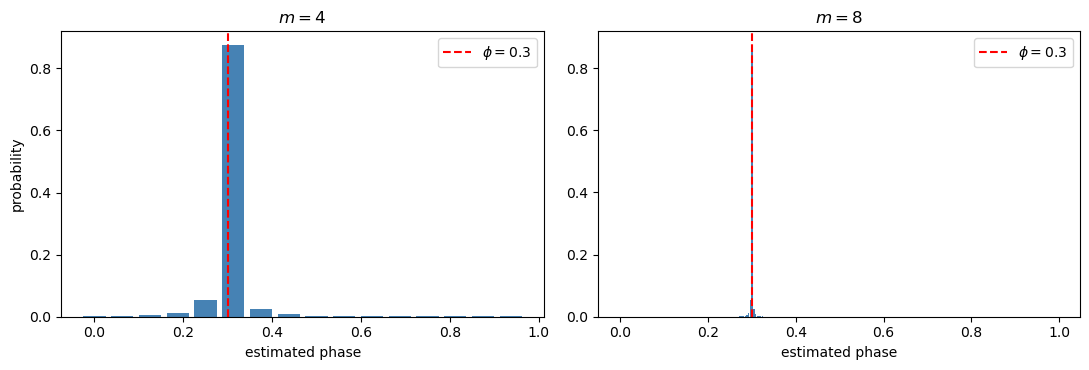

The envelope is the Dirichlet kernel
   P(m') = sin^2(pi 2^m delta) / (2^{2m} sin^2(pi delta)),
with delta the distance from phi to the representable value m'/2^m.
Its worst case gives the standard bound 4/pi^2 = 0.4053.


In [7]:
# the full distribution, and the Dirichlet kernel behind it
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, m in zip(axes, (4, 8)):
    dist = qpe.phase_estimation(qpe.phase_unitary(0.3), np.array([1.0+0j]), m)
    ax.bar(np.arange(len(dist)) / len(dist), dist,
           width=0.8/len(dist), color="steelblue")
    ax.axvline(0.3, color="r", ls="--", label=r"$\phi = 0.3$")
    ax.set_xlabel("estimated phase"); ax.set_title(f"$m = {m}$")
    ax.legend()
axes[0].set_ylabel("probability")
plt.tight_layout(); plt.show()
print("The envelope is the Dirichlet kernel")
print("   P(m') = sin^2(pi 2^m delta) / (2^{2m} sin^2(pi delta)),")
print("with delta the distance from phi to the representable value m'/2^m.")
print(f"Its worst case gives the standard bound 4/pi^2 = {4/math.pi**2:.4f}.")

In [8]:
models = [("Lipkin, N = 2", qpe.lipkin_qubit(2, 1.0, 1.0)),
          ("Lipkin, N = 4", qpe.lipkin_qubit(4, 1.0, 1.0)),
          ("pairing, 3 levels", qpe.pairing_pair_qubits(3, g=1.0)),
          ("Heisenberg, 3 sites", qpe.heisenberg_qubit(3, J=1.0)),
          ("Heisenberg, 4 sites", qpe.heisenberg_qubit(4, J=1.0)),
          ("Hubbard, 2 sites", qpe.hubbard_qubit(2, t=1.0, U=2.0))]

print(f"{'model':>21s} {'qubits':>7s} {'terms':>7s} {'max weight':>11s} "
      f"{'groups':>7s} {'E_0':>11s}")
for name, H in models:
    i = qpe.model_summary(name, H)
    print(f"{name:>21s} {i['n_qubits']:7d} {i['n_terms']:7d} "
          f"{i['max_weight']:11d} {i['groups']:7d} {i['spectrum'][0]:11.5f}")
print()
print("Lipkin and Heisenberg are weight two with no Jordan-Wigner tails, for")
print("opposite reasons: the Lipkin levels are degenerate so the quasispin")
print("operators are sums of single-qubit Paulis, and Heisenberg spins on")
print("different sites simply commute.  Hubbard pays the fermionic price.")
print()
print(f"check: 2-site Hubbard exact (U - sqrt(U^2+16t^2))/2 = "
      f"{(2 - math.sqrt(4+16))/2:.5f}")
print(f"check: 4-site Heisenberg ring = -2J = -2.00000")

                model  qubits   terms  max weight  groups         E_0
        Lipkin, N = 2       2       4           2       2    -1.41421
        Lipkin, N = 4       4      16           2       4    -4.00000
    pairing, 3 levels       3       9           2       4    -0.70530
  Heisenberg, 3 sites       3       9           2       4    -0.75000
  Heisenberg, 4 sites       4      12           2       2    -2.00000
     Hubbard, 2 sites       4      10           3       2    -1.23607

Lipkin and Heisenberg are weight two with no Jordan-Wigner tails, for
opposite reasons: the Lipkin levels are degenerate so the quasispin
operators are sums of single-qubit Paulis, and Heisenberg spins on
different sites simply commute.  Hubbard pays the fermionic price.

check: 2-site Hubbard exact (U - sqrt(U^2+16t^2))/2 = -1.23607
check: 4-site Heisenberg ring = -2J = -2.00000


In [9]:
print("Phase estimation on the models, exact ground state in, exact e^{-iHt}:")
print()
for name, H in models[:4]:
    spectrum, vectors = np.linalg.eigh(H)
    t = qpe.choose_time(H)
    print(f"{name}:  exact E_0 = {spectrum[0]:+.6f},  t = {t:.4f}")
    print(f"{'':>4s}{'m':>4s} {'outcome':>12s} {'p':>8s} {'E (QPE)':>12s} {'error':>10s}")
    for m in (4, 6, 8, 10):
        out = qpe.qpe_on_hamiltonian(H, vectors[:, 0], t, m)
        print(f"{'':>4s}{m:4d} {out['bits']:>12s} {out['probability']:8.4f} "
              f"{out['energy']:+12.6f} {abs(out['energy']-spectrum[0]):10.2e}")
    print()
print("The accuracy is set entirely by the control register, not by the size")
print("or nastiness of the physical system.  What the Hamiltonian controls is")
print("the cost of each application of U.")

Phase estimation on the models, exact ground state in, exact e^{-iHt}:

Lipkin, N = 2:  exact E_0 = -1.414214,  t = 2.8274
       m      outcome        p      E (QPE)      error
       4         1010   0.8957    -1.388889   2.53e-02
       6       101001   0.7811    -1.423611   9.40e-03
       8     10100011   0.9778    -1.414931   7.17e-04
      10   1010001100   0.6887    -1.414931   7.17e-04

Lipkin, N = 4:  exact E_0 = -4.000000,  t = 0.7069
       m      outcome        p      E (QPE)      error
       4         0111   0.8756    -3.888889   1.11e-01
       6       011101   0.8752    -4.027778   2.78e-02
       8     01110011   0.8751    -3.993056   6.94e-03


      10   0111001101   0.8751    -4.001736   1.74e-03

pairing, 3 levels:  exact E_0 = -0.705303,  t = 1.3306
       m      outcome        p      E (QPE)      error
       4         0010   0.5913    -0.590278   1.15e-01
       6       001010   0.5033    -0.737847   3.25e-02


       8     00100110   0.8300    -0.700955   4.35e-03
      10   0010011001   0.9893    -0.705566   2.63e-04

Heisenberg, 3 sites:  exact E_0 = -0.750000,  t = 2.5133
       m      outcome        p      E (QPE)      error
       4         0101   0.8756    -0.781250   3.12e-02
       6       010011   0.8752    -0.742188   7.81e-03
       8     01001101   0.8751    -0.751953   1.95e-03
      10   0100110011   0.8751    -0.749512   4.88e-04

The accuracy is set entirely by the control register, not by the size
or nastiness of the physical system.  What the Hamiltonian controls is
the cost of each application of U.


the Hamiltonian splits into 4 commuting groups

    r      E (QPE)  energy error   |U_trot - U|
    1    -0.625000      1.25e-01       4.52e-01
    2    -0.722656      2.73e-02       2.06e-01
    4    -0.742188      7.81e-03       1.01e-01
    8    -0.751953      1.95e-03       5.03e-02
   16    -0.751953      1.95e-03       2.50e-02


   32    -0.751953      1.95e-03       1.25e-02


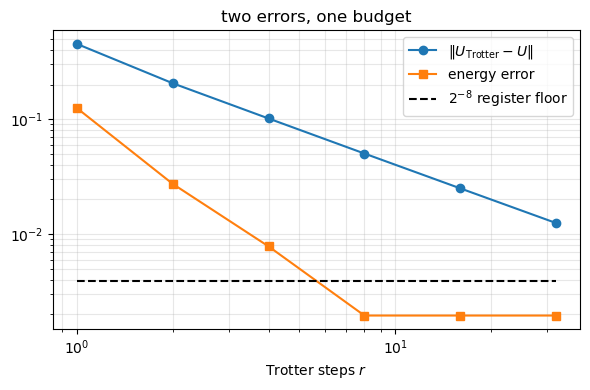

In [10]:
H = qpe.heisenberg_qubit(3, J=1.0)
spectrum, vectors = np.linalg.eigh(H)
ground, t = vectors[:, 0], qpe.choose_time(H)

coefficients = qpe.pauli_terms(H)
labels = [l for l in coefficients if l.count("I") != len(l)]
table = {"I": qpe.I2, "X": qpe.X, "Y": qpe.Y, "Z": qpe.Z}
terms = []
for group in qpe.commuting_groups(labels):
    block = np.zeros_like(H)
    for label in group:
        matrix = np.array([[1.0]], dtype=complex)
        for letter in label:
            matrix = np.kron(matrix, table[letter])
        block = block + coefficients[label] * matrix
    terms.append(block)
print(f"the Hamiltonian splits into {len(terms)} commuting groups\n")

exact_u = qpe.evolution_operator(H, t)
rs, e_err, u_err = [], [], []
print(f"{'r':>5s} {'E (QPE)':>12s} {'energy error':>13s} {'|U_trot - U|':>14s}")
for r in (1, 2, 4, 8, 16, 32):
    out = qpe.qpe_on_hamiltonian(H, ground, t, 8, terms=terms, trotter_steps=r)
    approx = qpe.trotter_operator(terms, t, r)
    rs.append(r); e_err.append(abs(out["energy"]-spectrum[0]))
    u_err.append(np.abs(approx-exact_u).max())
    print(f"{r:5d} {out['energy']:+12.6f} {e_err[-1]:13.2e} {u_err[-1]:14.2e}")

plt.figure(figsize=(6, 4))
plt.loglog(rs, u_err, "o-", label=r"$\|U_{\rm Trotter} - U\|$")
plt.loglog(rs, e_err, "s-", label="energy error")
plt.loglog(rs, [2.0**-8]*len(rs), "k--", label=r"$2^{-8}$ register floor")
plt.xlabel("Trotter steps $r$"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("two errors, one budget"); plt.tight_layout(); plt.show()

exact E_0 = -4.000000, E_1 = -3.162278

  |c_0|^2   p(E_0 bits)   p(E_1 bits)     modal E
   1.0000        0.8751        0.0001      -3.993
   0.8000        0.7001        0.1965      -3.993
   0.6000        0.5251        0.3930      -3.993
   0.3000        0.2625        0.6876      -3.160


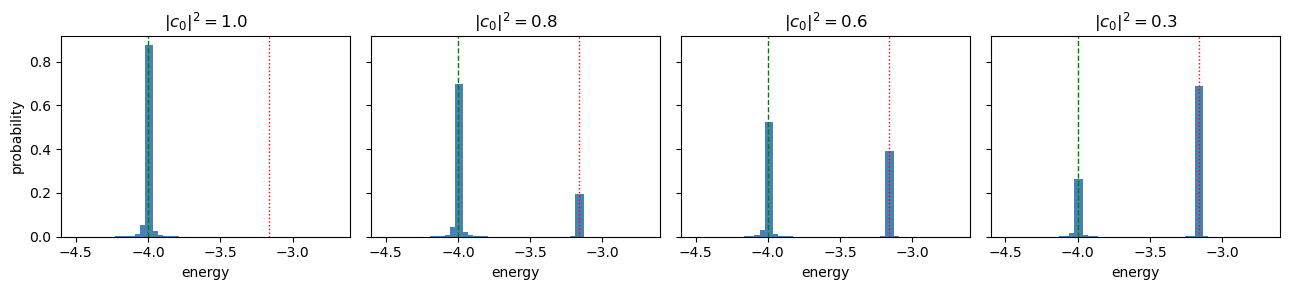

In [11]:
H = qpe.lipkin_qubit(4, 1.0, 1.0)
spectrum, vectors = np.linalg.eigh(H)
t = qpe.choose_time(H)
ground, excited = vectors[:, 0], vectors[:, 1]
i0 = int(qpe.qpe_on_hamiltonian(H, ground, t, 8)["bits"], 2)
i1 = int(qpe.qpe_on_hamiltonian(H, excited, t, 8)["bits"], 2)
print(f"exact E_0 = {spectrum[0]:+.6f}, E_1 = {spectrum[1]:+.6f}\n")
print(f"{'|c_0|^2':>9s} {'p(E_0 bits)':>13s} {'p(E_1 bits)':>13s} {'modal E':>11s}")
dists = []
for mix in (0.0, 0.2, 0.4, 0.7):
    trial = math.sqrt(1-mix)*ground + math.sqrt(mix)*excited
    trial /= np.linalg.norm(trial)
    out = qpe.qpe_on_hamiltonian(H, trial, t, 8)
    dists.append((abs(np.vdot(ground, trial))**2, out["distribution"]))
    print(f"{dists[-1][0]:9.4f} {out['distribution'][i0]:13.4f} "
          f"{out['distribution'][i1]:13.4f} {out['energy']:+11.3f}")

fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
for ax, (overlap, dist) in zip(axes, dists):
    energies = np.array([qpe.energy_from_phase(k/len(dist), t)
                         for k in range(len(dist))])
    ax.bar(energies, dist, width=0.06, color="steelblue")
    ax.axvline(spectrum[0], color="g", ls="--", lw=1)
    ax.axvline(spectrum[1], color="r", ls=":", lw=1)
    ax.set_xlim(-4.6, -2.6); ax.set_title(f"$|c_0|^2 = {overlap:.1f}$")
    ax.set_xlabel("energy")
axes[0].set_ylabel("probability")
plt.tight_layout(); plt.show()